In [13]:
import pandas as pd
import scripts.db as db
import matplotlib.pyplot as plt

# Data Ingestion


---


In [3]:
#database engine connection
engine = db.db_engine()

In [4]:
#dataframe create
df = pd.read_sql("SELECT * FROM gold.total_news", engine)

In [5]:
df.head(5)

,title,article_text,author,published_date,source_type,is_fake
0,overmillionamericansrollupsleevesforomicrontar...,healthexpertssaiditistooearlytopredictwhetherd...,carlakjohnsonap,2022-09-23,real_news,0
1,americanairlinesflyerchargedbannedforlifeafter...,hewassubduedbypassengersandcrewwhenhefledtothe...,marypapenfuss,2022-09-23,real_news,0
2,ofthefunniesttweetsaboutcatsanddogsthisweeksept,untilyouhaveadogyoudontunderstandwhatcouldbeeaten,elysewanshel,2022-09-23,real_news,0
3,thefunniesttweetsfromparentsthisweeksept,accidentallyputgrownuptoothpasteonmytoddlersto...,carolinebologna,2022-09-23,real_news,0
4,womanwhocalledcopsonblackbirdwatcherloseslawsu...,amycooperaccusedinvestmentfirmfranklintempleto...,ninagolgowski,2022-09-22,real_news,0


---


# Data Mining


### Pre Stage - Data Balancing


In [20]:
df_copy = df.copy()

is_fake
0    209522
1     12999
Name: count, dtype: int64


[]

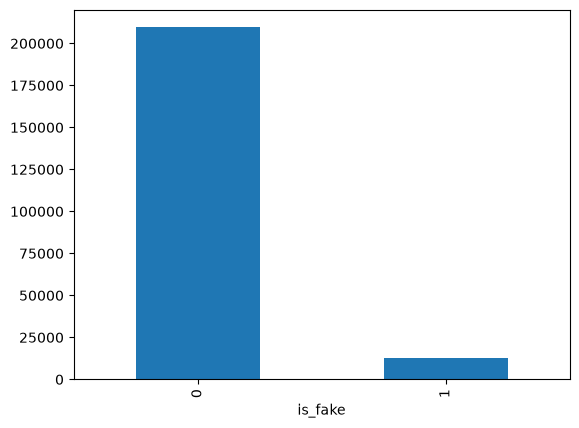

In [29]:
df_copy['is_fake'].value_counts().plot(kind='bar')
print(df_copy['is_fake'].value_counts())
plt.plot()

In [24]:
min = df_copy['is_fake'].value_counts().min()
df_balanced = df.groupby('is_fake').sample(n=min, random_state=42)

is_fake
0    12999
1    12999
Name: count, dtype: int64


[]

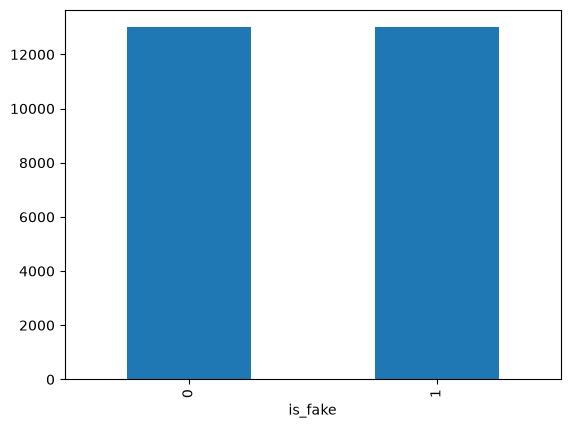

In [30]:
print(df_balanced['is_fake'].value_counts())
df_balanced['is_fake'].value_counts().plot(kind='bar')
plt.plot()

### Text Vectorization


In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
df_balanced.columns

Index(['title', 'article_text', 'author', 'published_date', 'source_type',
       'is_fake'],
      dtype='str')

In [34]:
vectorizer = TfidfVectorizer()
def vectorizer_func(column_text):
    return vectorizer.fit(column_text)